very intitative try and see the accuracy accordingly

creating new features to analyse data

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

import seaborn as sns

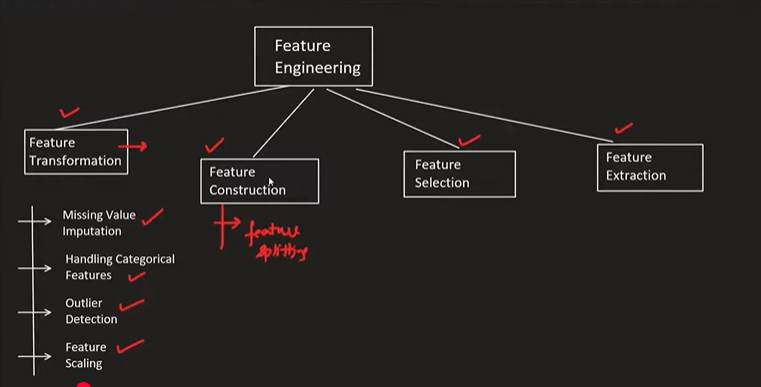

In [7]:
df=pd.read_csv('train.csv')[['Age','Pclass','SibSp','Parch','Survived']]

In [10]:
df.head()

,Age,Pclass,SibSp,Parch,Survived
0,22.0,3,1,0,0
1,38.0,1,1,0,1
2,26.0,3,0,0,1
3,35.0,1,1,0,1
4,35.0,3,0,0,0


In [9]:
df.dropna(inplace=True)

In [11]:
x=df.iloc[:,0:4]
y=df.iloc[:,-1]

In [12]:
np.mean(cross_val_score(LogisticRegression(),x,y,scoring='accuracy',cv=20))

np.float64(0.6933333333333332)

### Appyling Feature Construction

In [14]:
x['Family_size']=x['SibSp']+ x['Parch']+1  #+1 cos he himself also family

In [15]:
x.head()

,Age,Pclass,SibSp,Parch,Family_size
0,22.0,3,1,0,2
1,38.0,1,1,0,2
2,26.0,3,0,0,1
3,35.0,1,1,0,2
4,35.0,3,0,0,1


In [16]:
def myfun(num):
    if num==1:
        return 0 #alone
    elif num>1 and num<=4:
        return 1  #small fam
    else:
        return 2  #big fam

In [18]:
x['Family_type']=x['Family_size'].apply(myfun)

In [19]:
x.head()

,Age,Pclass,SibSp,Parch,Family_size,Family_type
0,22.0,3,1,0,2,1
1,38.0,1,1,0,2,1
2,26.0,3,0,0,1,0
3,35.0,1,1,0,2,1
4,35.0,3,0,0,1,0


In [21]:
x.drop(columns=['SibSp','Parch','Family_size'],inplace=True)

In [22]:
x.head()

,Age,Pclass,Family_type
0,22.0,3,1
1,38.0,1,1
2,26.0,3,0
3,35.0,1,1
4,35.0,3,0


In [23]:
np.mean(cross_val_score(LogisticRegression(),x,y,scoring='accuracy',cv=20))

np.float64(0.7003174603174602)

### Feature Splitting

In [26]:
dff=pd.read_csv('train.csv')

In [27]:
dff.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
#Name me se salutation bahar
dff['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [32]:
dff['Name'].str.split(', ',expand=True)[1].str.split('.',expand=True)

,0,1,2
0,Mr,Owen Harris,None
1,Mrs,John Bradley (Florence Briggs Thayer),None
2,Miss,Laina,None
3,Mrs,Jacques Heath (Lily May Peel),None
4,Mr,William Henry,None
...,...,...,...
886,Rev,Juozas,None
887,Miss,Margaret Edith,None
888,Miss,"Catherine Helen ""Carrie""",None
889,Mr,Karl Howell,None


In [33]:
dff['Tittle']=dff['Name'].str.split(', ',expand=True)[1].str.split('.',expand=True)[0]

In [31]:
dff[['Tittle','Name']]

,Tittle,Name
0,Mr,"Braund, Mr. Owen Harris"
1,Mrs,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,Miss,"Heikkinen, Miss. Laina"
3,Mrs,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,Mr,"Allen, Mr. William Henry"
...,...,...
886,Rev,"Montvila, Rev. Juozas"
887,Miss,"Graham, Miss. Margaret Edith"
888,Miss,"Johnston, Miss. Catherine Helen ""Carrie"""
889,Mr,"Behr, Mr. Karl Howell"


In [39]:
dff.groupby('Tittle')['Survived'].mean().sort_values(ascending=False)


Tittle
the Countess    1.000000
Mlle            1.000000
Sir             1.000000
Ms              1.000000
Lady            1.000000
Mme             1.000000
Mrs             0.792000
Miss            0.697802
Master          0.575000
Col             0.500000
Major           0.500000
Dr              0.428571
Mr              0.156673
Jonkheer        0.000000
Rev             0.000000
Don             0.000000
Capt            0.000000
Name: Survived, dtype: float64

In [40]:
#showa that married women havve high survival rate

In [41]:
dff['is_married']=0
dff['is_married'].iloc[dff['Tittle']=='Mrs']=1

C:\Users\suhav\AppData\Local\Temp\ipykernel_12400\188495618.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dff['is_married'].iloc[dff['Tittle']=='Mrs']=1
C:\Users\suhav\AppData\Local\Temp\ipykernel_12400\188495618.py:2: SettingWithCopyW

In [42]:
dff['is_married']

0      0
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    0
889    0
890    0
Name: is_married, Length: 891, dtype: int64

### Curse of Dimensionality

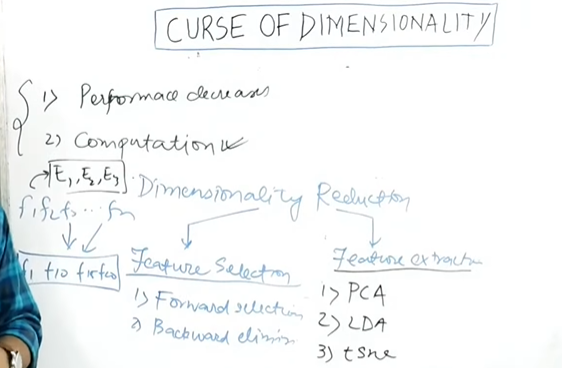